# 01 · Look at the data first

Before building anything, I want to see what customers actually write.

**My plan:**
1. Load the customer messages
2. Count how many of each type (intent) there are
3. Look at some real examples
4. Look at the fake orders the agent will use

> First, run `python run.py data` in the terminal once. It creates the files in `data/`.

In [1]:
import sys
sys.path.append("..")   # so Python can find the budget_agent folder

import pandas as pd
pd.set_option("display.max_colwidth", 80)

## Step 1: Load the messages

In [2]:
from budget_agent import data

messages = data.load_messages()
messages.head()

,id,text,true_intent,split
0,0,help with a shipping address modification,change_shipping_address,train
1,1,how do I make a reclamation?,complaint,test
2,2,where can i see if there are any news on the reimbursement,track_refund,train
3,3,I don't know what I have to do to speak to somebody,contact_human_agent,train
4,4,I don't know how I can track my rebate,track_refund,train


In [3]:
messages.shape

(1620, 4)

1,620 messages. Each one has:
- `text`: what the customer wrote
- `true_intent`: what they want (the correct answer)
- `split`: `train` (for learning) or `test` (for checking)

## Step 2: How many of each intent?

In [4]:
messages.true_intent.value_counts()

true_intent
change_shipping_address     60
complaint                   60
track_refund                60
contact_human_agent         60
place_order                 60
delivery_period             60
get_invoice                 60
check_invoice               60
create_account              60
edit_account                60
delete_account              60
cancel_order                60
delivery_options            60
check_refund_policy         60
check_payment_methods       60
set_up_shipping_address     60
contact_customer_service    60
change_order                60
track_order                 60
newsletter_subscription     60
review                      60
get_refund                  60
switch_account              60
recover_password            60
payment_issue               60
registration_problems       60
check_cancellation_fee      60
Name: count, dtype: int64

27 intents, 60 messages each. Nicely balanced, so no intent is ignored by the model later.

In [5]:
messages.split.value_counts()

split
train    1080
test      540
Name: count, dtype: int64

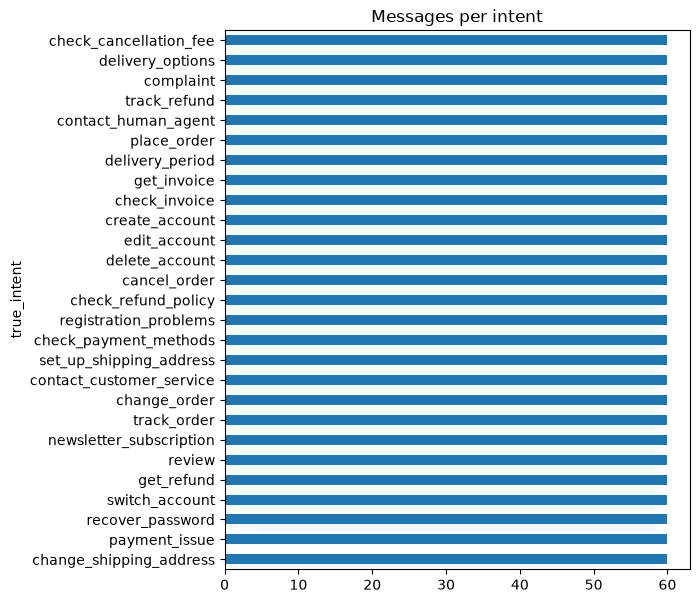

In [6]:
messages.true_intent.value_counts().sort_values().plot.barh(figsize=(6, 7), title="Messages per intent");

## Step 3: Read some real examples

In [7]:
for intent in ["track_order", "get_refund", "complaint", "check_payment_methods"]:
    print(intent.upper())
    for text in messages[messages.true_intent == intent].text.head(3):
        print("   ", text)
    print()

TRACK_ORDER
    need help seeing the eta of the purchase NM10125
    see purchase NM10114 current status
    where do I check the current status of order NM10047?

GET_REFUND
    what do i need to do to obtain reimbursements of my money
    i do not know what i need to do to request a compensation
    I have got to ask for rebates

COMPLAINT
    how do I make a reclamation?
    help to make a customer complaint
    I am trying to lodge a customer reclamation

CHECK_PAYMENT_METHODS
    i want assistance to list the payment methods
    I have to list the payment modalities, I need assistance
    I need to see your available payment methods, how to do it?



**What I noticed:**
- The same request is written in many ways ("track my order", "where is my package").
- Some messages have typos already.
- These messages are quite clean, though. Real customers are messier.

## Step 4: The messy messages

So I wrote 50 messy messages myself: typos, Hinglish, angry customers, two requests in one message.

In [8]:
messy = data.load_messy()
messy.sample(10, random_state=1)

,text,true_intent
27,what delivery options r there,delivery_options
35,reset pasword plz,recover_password
40,need the bill for my last order,get_invoice
38,unsubscribe me from ur emails,newsletter_subscription
2,"wheres my stuf, order no NM10101",track_order
3,tracking for NM10230 pls,track_order
48,refund NM10033 now and also change my address for NM10045,get_refund
29,do you take upi?,check_payment_methods
46,i want to add one more item to order NM10003,change_order
31,whats ur return policy,check_refund_policy


I expect these to be **much harder** for a simple ML model. Let's remember that for notebook 03.

## Step 5: The fake orders

In [9]:
orders = data.load_orders()
orders.head()

,order_id,customer_name,city,product,quantity,amount_inr,order_date,status,delivery_date
0,NM10000,Meera Reddy,Bengaluru,Phone Case,1,499,2026-10-03,Delayed,2026-10-12
1,NM10001,Neha Sharma,Mumbai,Gaming Mouse,1,2199,2026-08-22,Delayed,2026-10-09
2,NM10002,Aarav Rao,Pune,Smart Watch,1,5999,2026-09-20,Delivered,2026-09-26
3,NM10003,Kabir Sharma,Bengaluru,Gaming Mouse,2,4398,2026-09-20,Delivered,2026-09-26
4,NM10004,Arjun Singh,Delhi,Gaming Mouse,2,4398,2026-09-13,Delivered,2026-09-16


In [10]:
orders.status.value_counts()

status
Delivered     143
Delayed        46
Processing     38
Shipped        37
Cancelled      36
Name: count, dtype: int64

A mix of statuses, so the agent will meet every situation: refunds allowed, refunds refused, cancels allowed, cancels refused.

## What I learned
- 27 intents, balanced, with a train/test split ready.
- Clean messages (Bitext) + messy messages (mine) = a fair test.
- Next: talk to an LLM for the first time → `02_first_chat_with_an_llm.ipynb`